<div style="display: flex; background-color: #FF6B6B;" >
<h1 style="margin: auto; padding: 30px; color: white; ">Étude de marché pour l'exportation de volaille</h1>
</div>

<div style="background-color: #4ECDC4;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">1.1 - Importation des librairies</h3>
</div>

In [42]:
# Importation des librairies
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">1.2 - Importation du fichier</h3>
</div>

In [43]:
df_volaille = pd.read_excel(
    "../data/df_final.xlsx"
)

<div style="background-color: #4ECDC4;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Etape 2 - Analyse exploratoire du fichier</h2>
</div>

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">2.1 - Exploration du fichier</h3>
</div>

In [44]:
# Dimension du dataset
df_volaille.info()

<class 'pandas.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Name                  181 non-null    str    
 1   ISO 3                 181 non-null    str    
 2   IC                    179 non-null    str    
 3   CC                    181 non-null    float64
 4   PV                    181 non-null    float64
 5   Internet              181 non-null    float64
 6   Chomage               181 non-null    float64
 7   Tourisme              169 non-null    float64
 8   Evolution tourisme    159 non-null    float64
 9   LPI                   155 non-null    float64
 10  Distance capitale     181 non-null    int64  
 11  RL                    181 non-null    float64
 12  RQ                    181 non-null    float64
 13  Population            181 non-null    float64
 14  Evolution population  181 non-null    float64
 15  Production volaille   155 non-null

In [45]:
# Variables PESTEL
pestel = [
    "CC",
    "PV",
    "Internet",
    "Chomage",
    "Tourisme",
    "Evolution tourisme",
    "LPI",
    "Distance capitale",
    "RL",
    "RQ",
    "Population",
    "Evolution population",
    "Production volaille",
    "Importation volaille",
    "Dispo alim volaille",
]

In [46]:
# Statistiques descriptives des variables PESTEL
df_volaille[pestel].describe()

,CC,PV,Internet,Chomage,Tourisme,Evolution tourisme,LPI,Distance capitale,RL,RQ,Population,Evolution population,Production volaille,Importation volaille,Dispo alim volaille
count,181.000000,181.000000,181.000000,181.00000,1.690000e+02,159.000000,155.000000,181.000000,181.000000,181.000000,1.810000e+02,181.000000,155.000000,146.000000,165.000000
mean,47.172210,64.909993,52.505766,7.04232,1.240206e+07,74.967355,2.877290,5904.751381,56.074561,55.457348,4.057659e+04,5.591199,780.529032,102.417808,7.003939
std,20.341685,15.198734,28.834513,5.66963,2.885547e+07,125.486823,0.564983,3822.468495,16.510755,14.654536,1.494901e+05,5.277075,2596.743181,198.055365,5.547535
min,14.170000,21.244270,0.000000,0.00000,0.000000e+00,-100.000000,1.950000,0.000000,18.844823,24.750000,3.367100e+01,-12.681196,1.000000,1.000000,0.040000
25%,31.070000,54.492316,25.510401,3.41000,9.230000e+05,17.767580,2.450000,2628.000000,43.497287,44.120000,2.205080e+03,1.967052,19.500000,6.250000,1.970000
50%,43.310000,65.692010,55.799999,5.23800,2.517000e+06,46.524560,2.720000,5513.000000,52.483219,53.190000,8.829628e+03,4.958200,81.000000,23.000000,6.320000
75%,62.060000,78.180968,77.615257,9.31600,8.815000e+06,98.420690,3.225000,8570.000000,67.646093,64.430000,2.912147e+04,9.097374,478.000000,102.750000,9.930000
max,94.470000,91.561385,99.546600,27.03500,2.072740e+08,810.714286,4.200000,19020.000000,92.925652,89.430000,1.421022e+06,23.935417,21914.000000,1069.000000,27.870000


In [47]:
# Vérifications de doublons dans la variable Name
print(f"La colonne name contient {(df_volaille["Name"].duplicated().sum())} doublons")

La colonne name contient 0 doublons


Des variables avec des valeurs manquantes, aucun pays en doublons et certaines valeurs à investiguer (0 en chomage et en internet)

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">2.2 - Investigation des NaN</h3>
</div>

In [48]:
# Comptage des NaN par pays
df_volaille["nb_nan"] = df_volaille[pestel].isnull().sum(axis=1)
print("Distribution des valeurs manquantes par pays")
print(df_volaille["nb_nan"].value_counts().sort_index())

Distribution des valeurs manquantes par pays
nb_nan
0    105
1     43
2     17
3      7
4      7
5      1
6      1
Name: count, dtype: int64


In [49]:
# Consultation des pays avec 3 NaN ou plus
print(
    df_volaille[df_volaille["nb_nan"] >= 3][["Name", "nb_nan"]].to_string(index=False)
)

                 Name  nb_nan
              Bahrain       3
               Bhutan       3
    Brunei Darussalam       4
              Burundi       3
              Comoros       4
    Equatorial Guinea       3
              Eritrea       4
        Liechtenstein       5
     Marshall Islands       4
Micronesia, Fed. Sts.       6
     Papua New Guinea       3
                Qatar       4
           San Marino       4
           Seychelles       4
            Singapore       3
 Syrian Arab Republic       3


Avec 15 variables présentes, nous fixerons un seuil de ~13% soit un seuil strict de maximum 2 valeurs manquantes par pays. Au-delà, le profil du pays serait trop incomplet.

In [50]:
# Suppression des pays avec plus de 2 NaN
df_volaille = df_volaille[df_volaille["nb_nan"] <= 2]

In [51]:
# Suppression de la colonne nb_nan
df_volaille = df_volaille.drop(columns=["nb_nan"])

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">2.3 - Variables Internet et Chômage</h3>
</div>

In [52]:
# Affichage des pays à 0 en taux de chômage et d'accès internet
df_internet_chomage_0 = df_volaille[
    (df_volaille["Internet"] == 0) | (df_volaille["Chomage"] == 0)
]
df_internet_chomage_0

,Name,ISO 3,IC,CC,PV,Internet,Chomage,Tourisme,Evolution tourisme,LPI,Distance capitale,RL,RQ,Population,Evolution population,Production volaille,Importation volaille,Dispo alim volaille
45,Dominica,DMA,Upper middle income,60.43,84.844524,69.619698,0.000,230000.000,-50.854701,NaN,6944,68.996080,57.61,71.458,0.622395,NaN,4.0,11.52
64,Grenada,GRD,Upper middle income,56.98,81.497972,54.200001,0.000,468000.000,9.345794,NaN,7083,66.587149,54.10,110.874,2.499769,1.0,7.0,15.50
137,Samoa,WSM,Upper middle income,60.32,84.155398,0.000000,9.400,158000.000,29.508197,NaN,16059,73.772394,56.15,195.352,2.429765,NaN,17.0,21.88
152,St. Kitts and Nevis,KNA,High income,57.29,77.189475,67.784401,0.000,1194000.000,124.015009,NaN,6738,71.633086,62.56,52.045,3.400000,NaN,4.0,19.22
168,Turkmenistan,TKM,Upper middle income,18.45,61.984095,0.000000,4.035,0.000,NaN,2.41,4632,31.487999,26.66,5757.667,7.291492,20.0,9.0,1.53
176,Vanuatu,VUT,Lower middle income,46.51,80.456464,0.000000,5.247,332700.012,NaN,NaN,16172,65.093351,49.42,285.510,11.251388,1.0,4.0,4.05
177,"Venezuela, RB",VEN,NaN,18.45,42.320681,0.000000,5.045,429000.000,-38.888889,2.23,7643,18.844823,25.99,29402.484,-1.270000,600.0,25.0,7.23


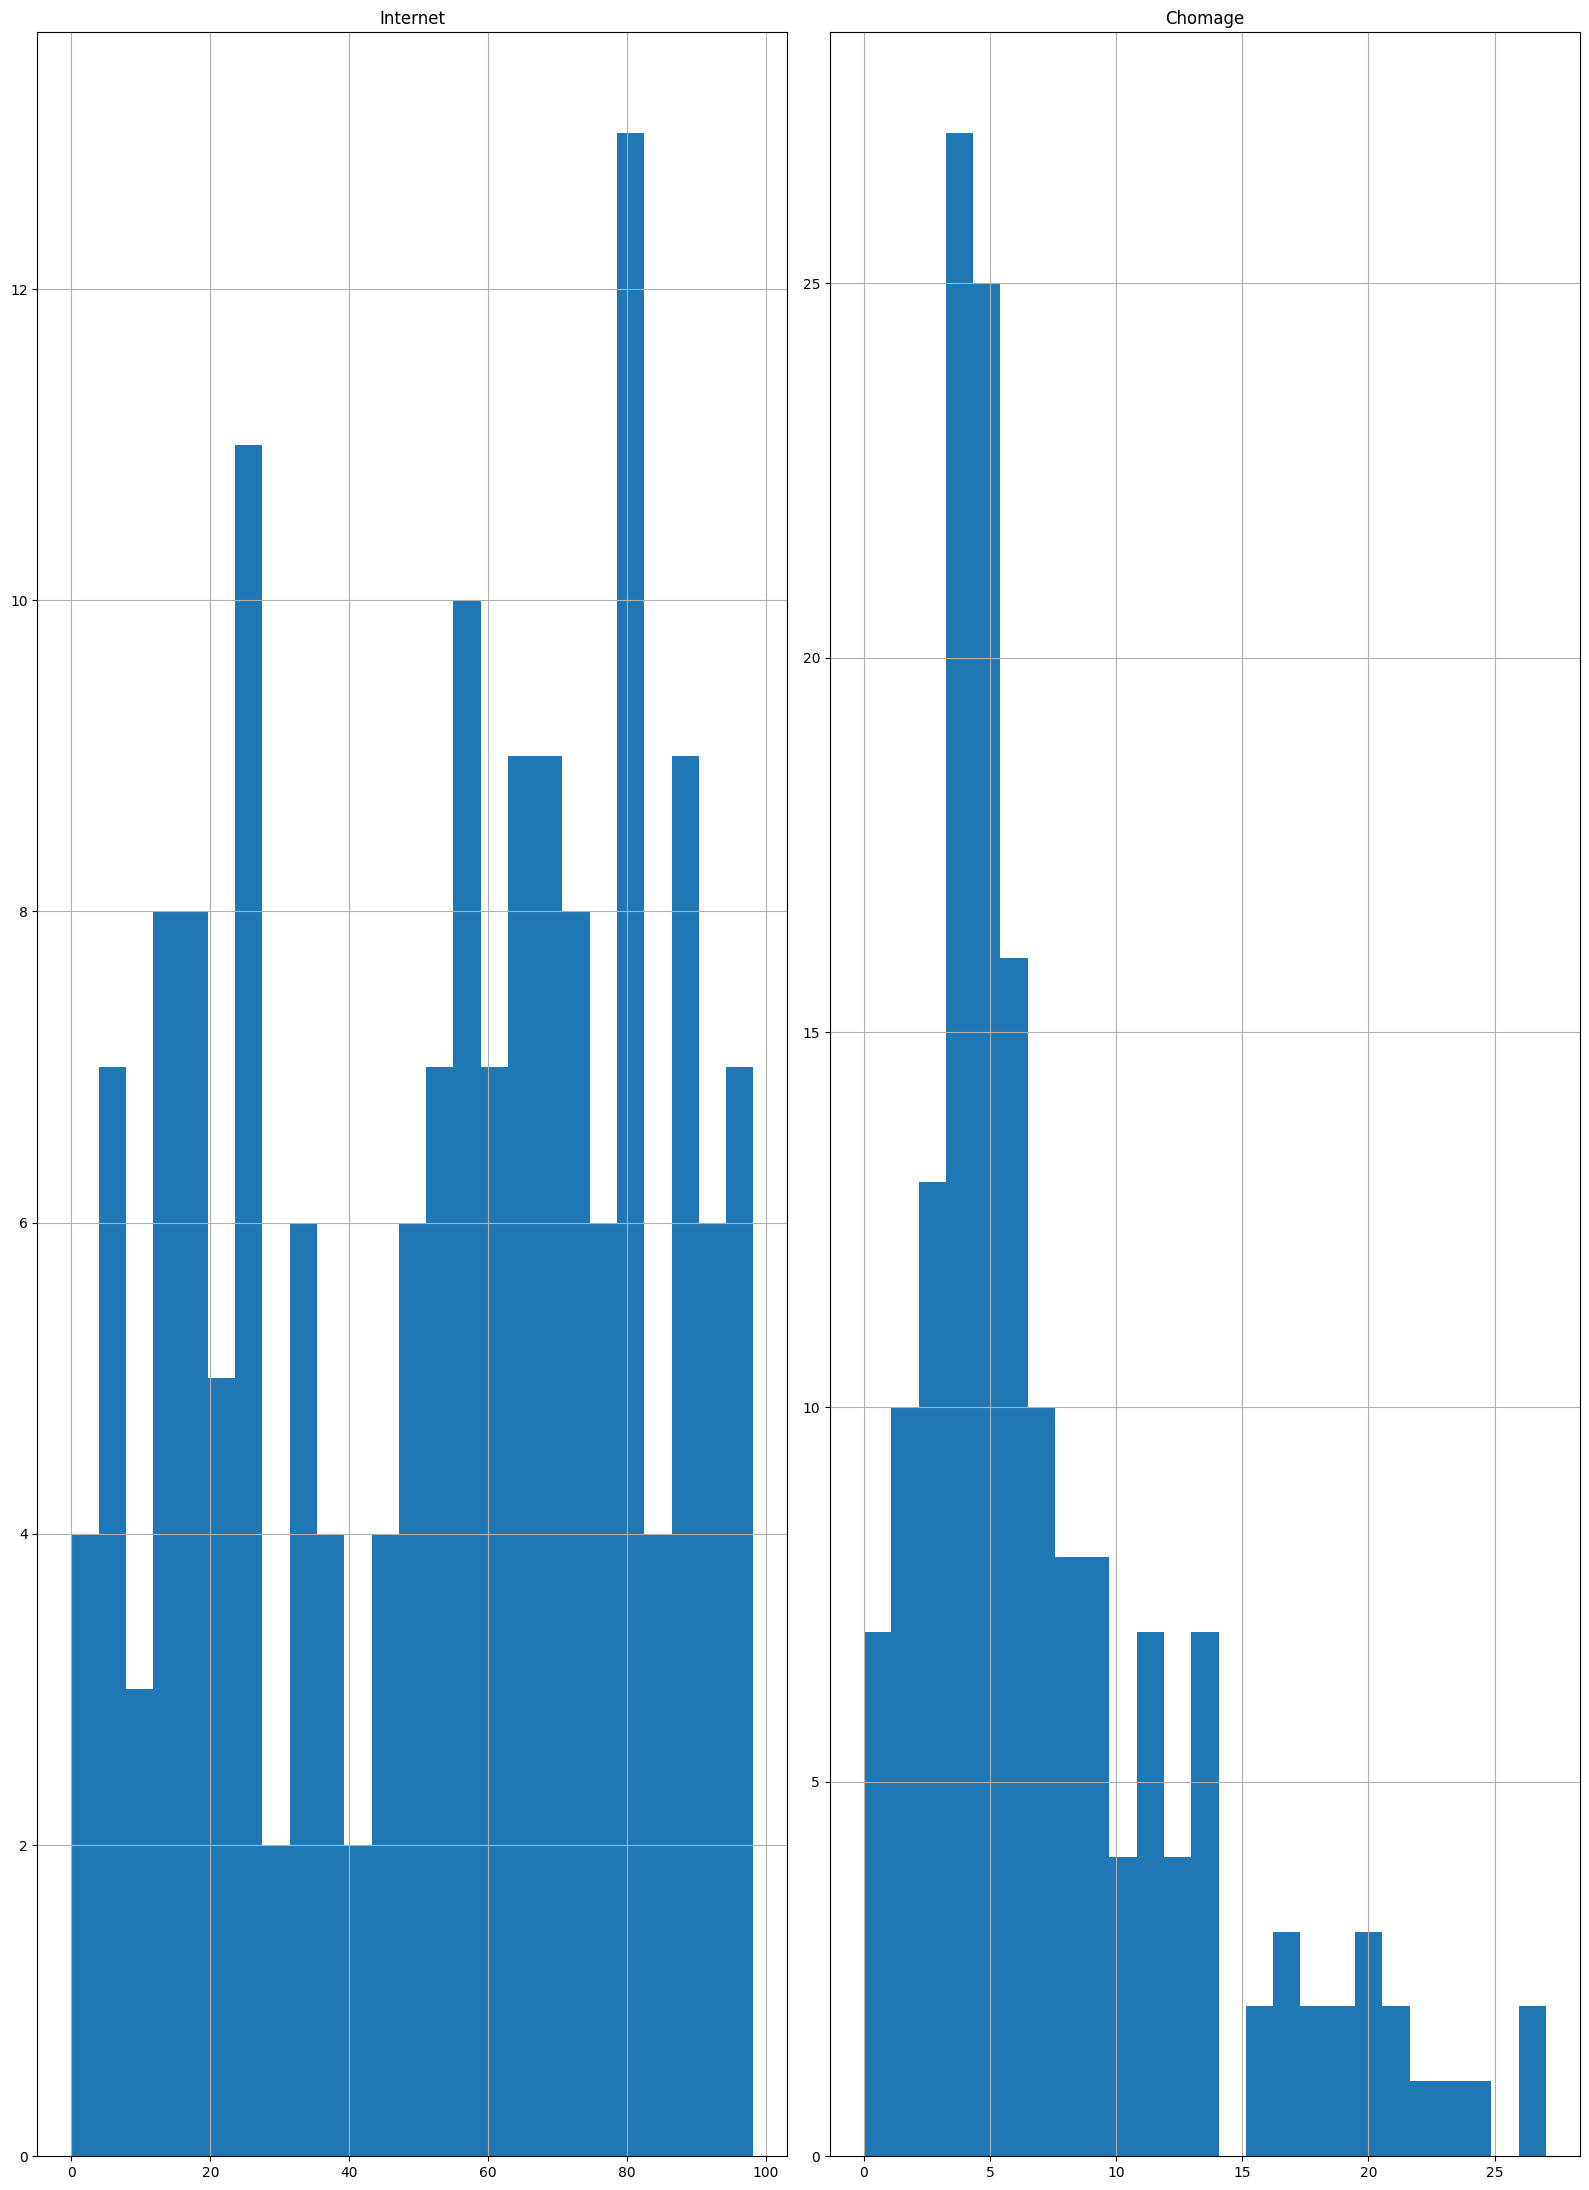

In [53]:
# Visualisation de la distribution des variables
df_volaille[["Internet", "Chomage"]].hist(bins=25, figsize=(16, 22))
plt.tight_layout()
plt.show()

Le chômage a une distribution fortement asymétrique tandis que l'internet est bimodal avec deux concentrations distinctes. Nous utiliserons donc l'imputation par la médiane pour ces deux variables.


In [54]:
# Attribution du dernier Income classification connus pour le Venezuela
df_volaille.loc[df_volaille["Name"] == "Venezuela, RB", "IC"] = "Upper middle income"

In [55]:
# Transformation des 0 en NaN
df_volaille.loc[df_volaille["Internet"] == 0, "Internet"] = np.nan
df_volaille.loc[df_volaille["Chomage"] == 0, "Chomage"] = np.nan

In [56]:
# Imputation par la médiane en fonction d'Income classification qui classe les pays par groupe en fonction de leur richesse
for col in ["Internet", "Chomage"]:
    df_volaille[col] = df_volaille.groupby("IC")[col].transform(
        lambda x: x.fillna(x.median())
    )

In [57]:
# Vérification de l'imputation
df_volaille[pestel].describe()

,CC,PV,Internet,Chomage,Tourisme,Evolution tourisme,LPI,Distance capitale,RL,RQ,Population,Evolution population,Production volaille,Importation volaille,Dispo alim volaille
count,165.000000,165.000000,164.000000,164.000000,1.560000e+02,149.000000,144.000000,165.000000,165.000000,165.000000,1.650000e+02,165.000000,154.000000,145.000000,165.000000
mean,46.733212,64.563339,54.159778,7.557274,1.318025e+07,73.652885,2.897222,5764.739394,56.045060,55.746242,4.418836e+04,5.520150,785.493506,103.096552,7.003939
std,19.688193,14.424508,26.936420,5.599068,2.987227e+07,112.513330,0.557373,3753.790505,16.213759,14.246516,1.561308e+05,5.079123,2604.477382,198.571402,5.547535
min,14.170000,21.244270,4.000000,0.141000,0.000000e+00,-100.000000,1.950000,0.000000,18.844823,25.990000,5.204500e+01,-5.434483,1.000000,1.000000,0.040000
25%,31.640000,54.734172,27.200001,3.771750,1.022500e+06,19.270239,2.505000,2285.000000,43.633055,44.500000,2.944791e+03,1.828215,20.000000,7.000000,1.970000
50%,42.550000,65.410950,58.025813,5.592000,3.061000e+06,46.524560,2.750000,5503.000000,51.872463,53.750000,9.785843e+03,4.899617,83.000000,23.000000,6.320000
75%,59.880000,77.222615,76.966724,9.575000,1.048500e+07,98.630137,3.240000,8533.000000,67.620156,64.430000,3.144430e+04,9.095768,485.500000,104.000000,9.930000
max,94.470000,91.388422,98.255201,27.035000,2.072740e+08,778.048780,4.200000,19020.000000,92.925652,89.430000,1.421022e+06,23.935417,21914.000000,1069.000000,27.870000


In [58]:
# Investigation du dernier NaN
df_volaille[df_volaille["Internet"].isna() | df_volaille["Chomage"].isna()][
    ["Name", "ISO 3 ", "IC", "Internet", "Chomage"]
]

,Name,ISO 3,IC,Internet,Chomage
54,Ethiopia,ETH,NaN,NaN,NaN


In [59]:
# Ligne de l'Ethiopie
df_volaille[df_volaille["Name"] == "Ethiopia"]

,Name,ISO 3,IC,CC,PV,Internet,Chomage,Tourisme,Evolution tourisme,LPI,Distance capitale,RL,RQ,Population,Evolution population,Production volaille,Importation volaille,Dispo alim volaille
54,Ethiopia,ETH,NaN,36.42,39.937663,NaN,NaN,933000.0,143.603133,NaN,5513,43.497287,40.69,106399.924,11.546924,14.0,1.0,0.04


L'Éthiopie comporte 3 NaN et sera donc supprimée de l'étude


In [60]:
# Suppression du pays
df_volaille = df_volaille[df_volaille["Name"] != "Ethiopia"].copy()

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">2.4 Variables Tourisme et Evolution tourisme </h3>
</div>

In [61]:
# Consultation des NaN
df_volaille[df_volaille["Tourisme"].isna() | df_volaille["Evolution tourisme"].isna()][
    ["Name", "IC", "Tourisme", "Evolution tourisme"]
]

,Name,IC,Tourisme,Evolution tourisme
0,Afghanistan,Low income,NaN,NaN
30,Central African Republic,Low income,1.070000e+05,NaN
36,"Congo, Rep.",Lower middle income,1.510000e+05,NaN
44,Djibouti,Lower middle income,NaN,-100.0
58,Gabon,Upper middle income,NaN,NaN
62,Ghana,Lower middle income,NaN,-100.0
63,Greece,High income,3.016100e+07,NaN
77,Iraq,Upper middle income,NaN,-100.0
93,Liberia,Low income,NaN,NaN
98,Madagascar,Low income,2.850000e+05,NaN


In [62]:
# Imputation des NaN par 0
df_volaille["Tourisme"] = df_volaille["Tourisme"].fillna(0)
df_volaille["Evolution tourisme"] = df_volaille["Evolution tourisme"].fillna(0)

Les valeurs manquantes pour ces variables sont essentiellement dues à une absence de statistiques touristiques officielles (instabilité politique, états de petite taille). Nous les avons imputées à 0 considérant que l'absence de données traduit une activité touristique non significative.


In [63]:
# Pays avec evolution de tourisme à -100
df_volaille[df_volaille["Evolution tourisme"] == -100][
    ["Name", "ISO 3 ", "IC", "Tourisme", "Evolution tourisme"]
]

,Name,ISO 3,IC,Tourisme,Evolution tourisme
44,Djibouti,DJI,Lower middle income,0.0,-100.0
62,Ghana,GHA,Lower middle income,0.0,-100.0
77,Iraq,IRQ,Upper middle income,0.0,-100.0
121,Nigeria,NGA,Lower middle income,0.0,-100.0
125,Pakistan,PAK,Lower middle income,0.0,-100.0


In [64]:
# Imputation des pays à -100 par 0
df_volaille.loc[df_volaille["Evolution tourisme"] == -100, "Evolution tourisme"] = 0

Les valeurs d'évolution de tourisme sont calculées par rapport au tourisme initiale, ce qui explique pourquoi certains pays ont -100 (division impossible). Ils ont également été mis à 0 car les deux variables sont liées.

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">2.5 Variable LPI </h3>
</div>

In [65]:
# Consultation des NaN
df_volaille[df_volaille["LPI"].isna()][["Name", "IC", "LPI"]]

,Name,IC,LPI
8,Azerbaijan,Upper middle income,NaN
12,Barbados,High income,NaN
15,Belize,Upper middle income,NaN
20,Botswana,Upper middle income,NaN
26,Cabo Verde,Upper middle income,NaN
45,Dominica,Upper middle income,NaN
53,Eswatini,Lower middle income,NaN
64,Grenada,Upper middle income,NaN
97,"Macao SAR, China",High income,NaN
113,Mozambique,Low income,NaN


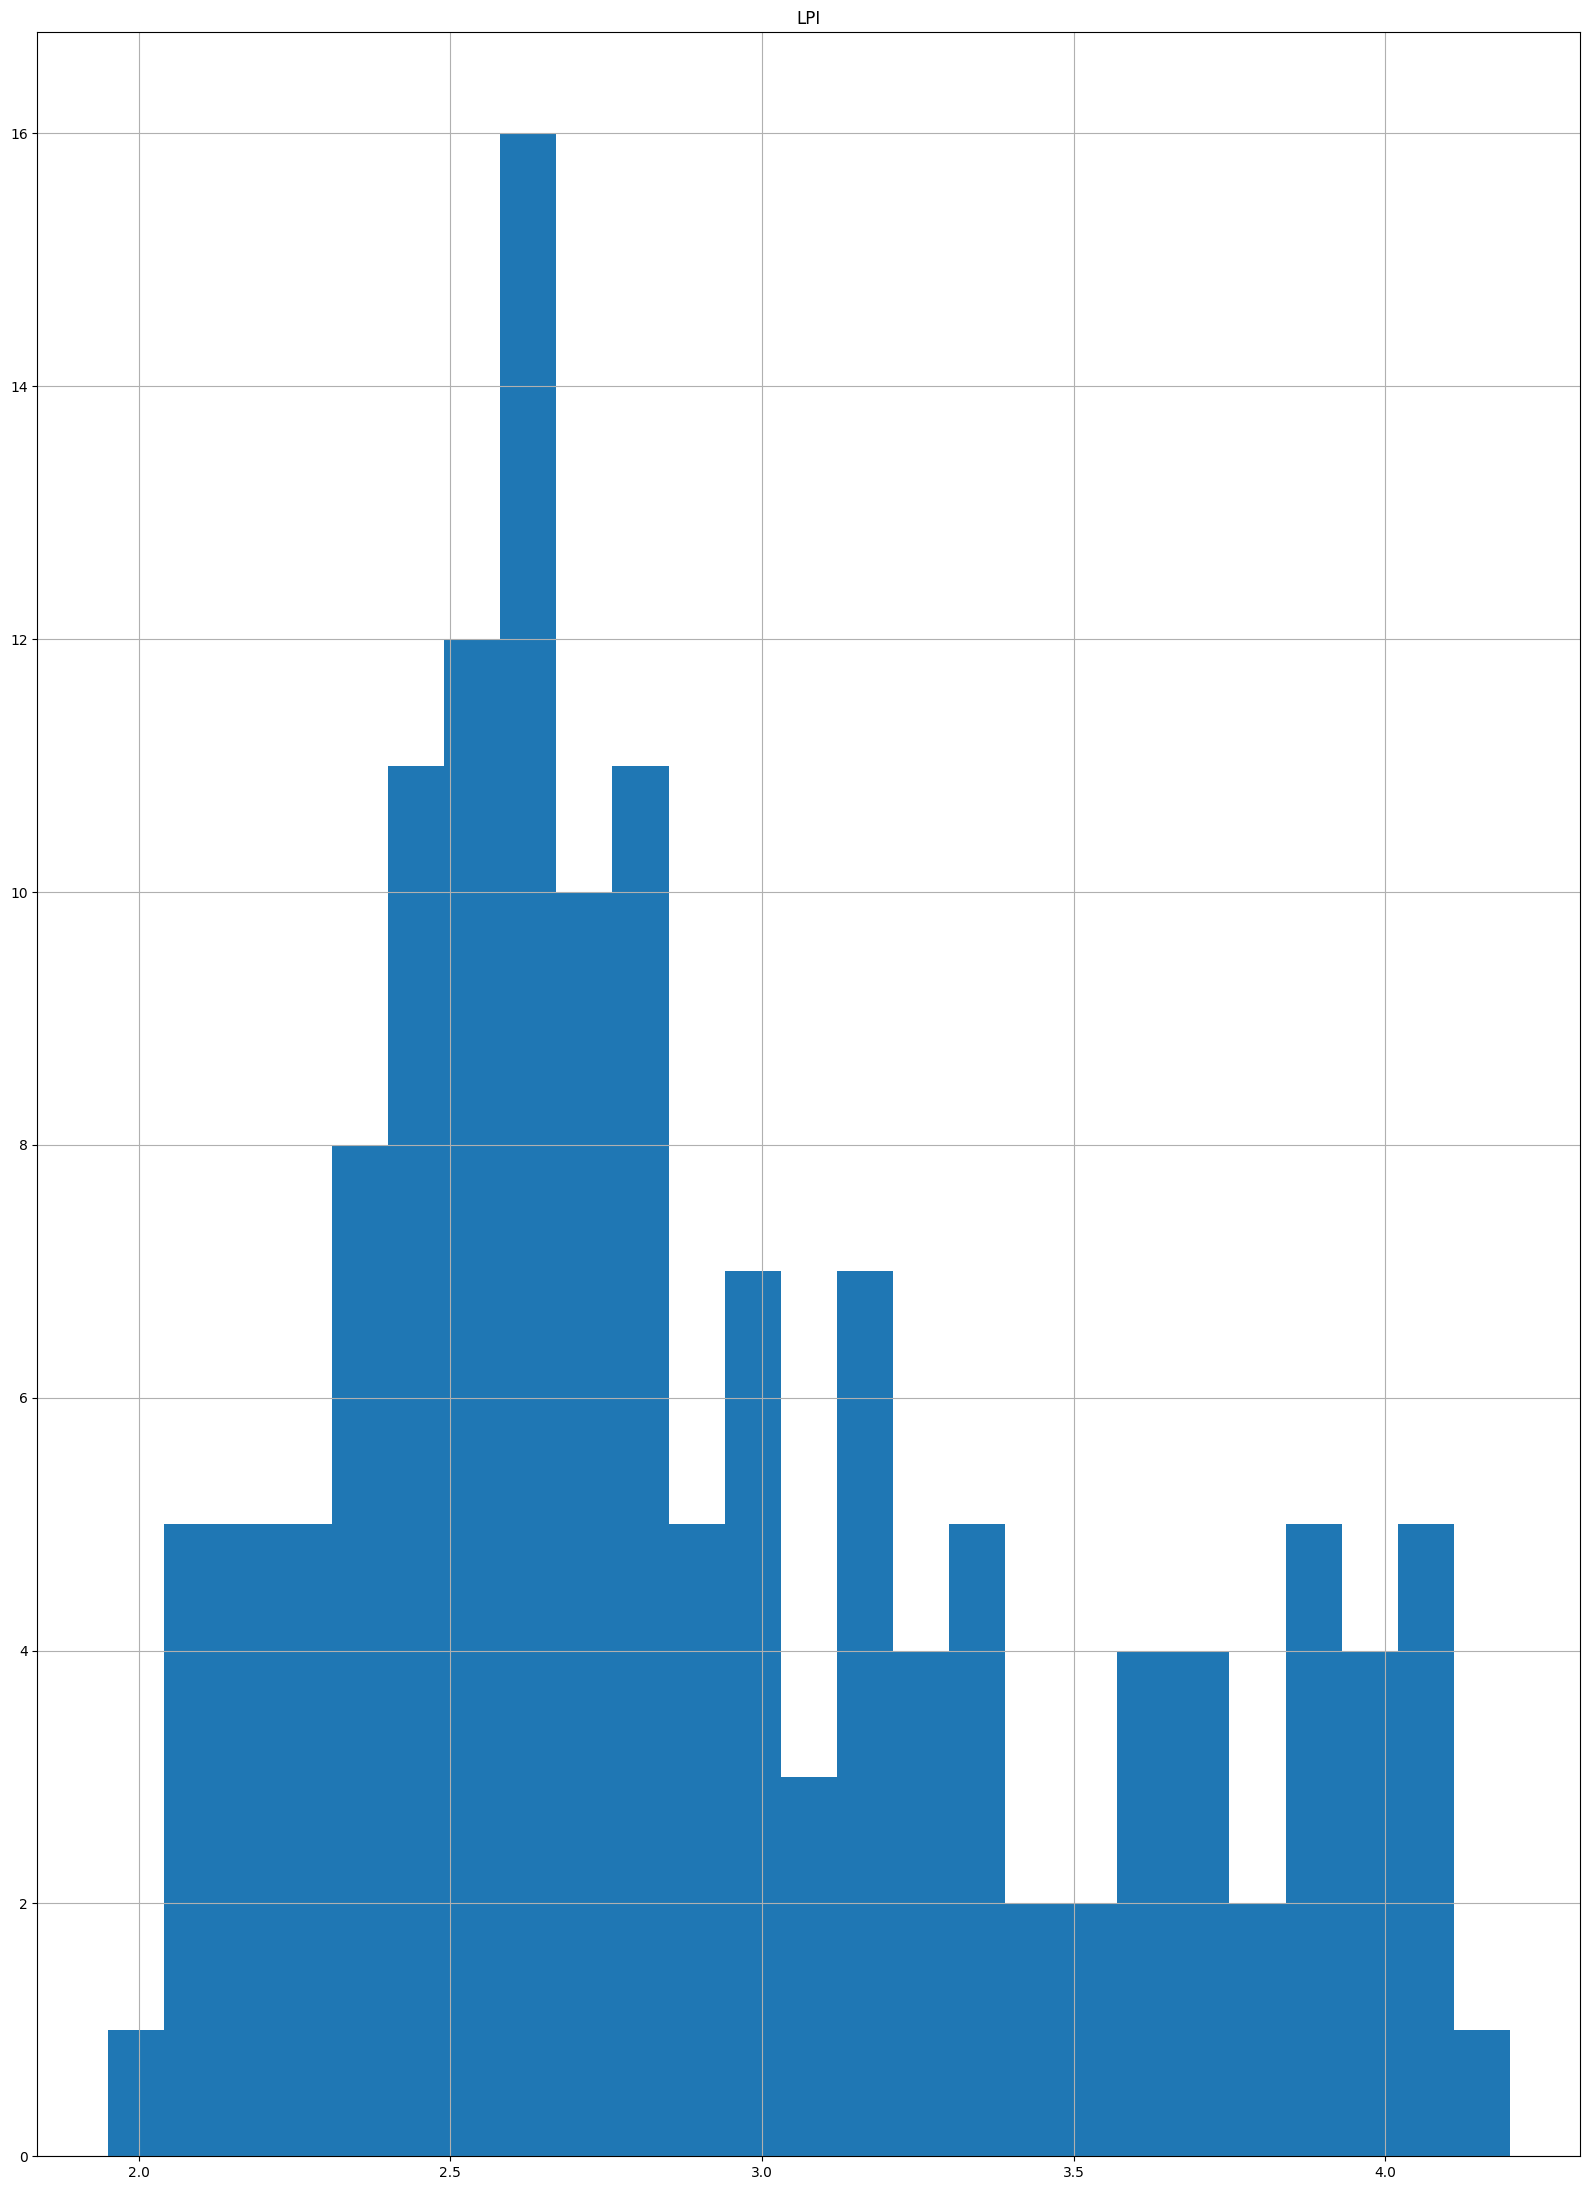

In [66]:
# Visualisation de la distribution de la variable
df_volaille[["LPI"]].hist(bins=25, figsize=(16, 22))
plt.tight_layout()
plt.show()

LPI est légèrement asymétrique à droite, nous imputerons donc par la médiane

In [ ]:
# Imputation par la médiane
for col in ["LPI"]:
    df_volaille[col] = df_volaille.groupby("IC")[col].transform(
        lambda x: x.fillna(x.median())
    )

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">2.6 Variables importation et production volaille </h3>
</div>

In [68]:
# Consultation des NaN
df_volaille[
    df_volaille["Production volaille"].isna()
    | df_volaille["Importation volaille"].isna()
][["Name", "IC", "Production volaille", "Importation volaille"]]

,Name,IC,Production volaille,Importation volaille
11,Bangladesh,Lower middle income,249.0,NaN
15,Belize,Upper middle income,20.0,NaN
24,Burkina Faso,Low income,46.0,NaN
28,Cameroon,Lower middle income,81.0,NaN
44,Djibouti,Lower middle income,NaN,3.0
45,Dominica,Upper middle income,NaN,4.0
47,Ecuador,Upper middle income,340.0,NaN
68,Guyana,High income,31.0,NaN
74,India,Lower middle income,3545.0,NaN
79,Israel,High income,629.0,NaN


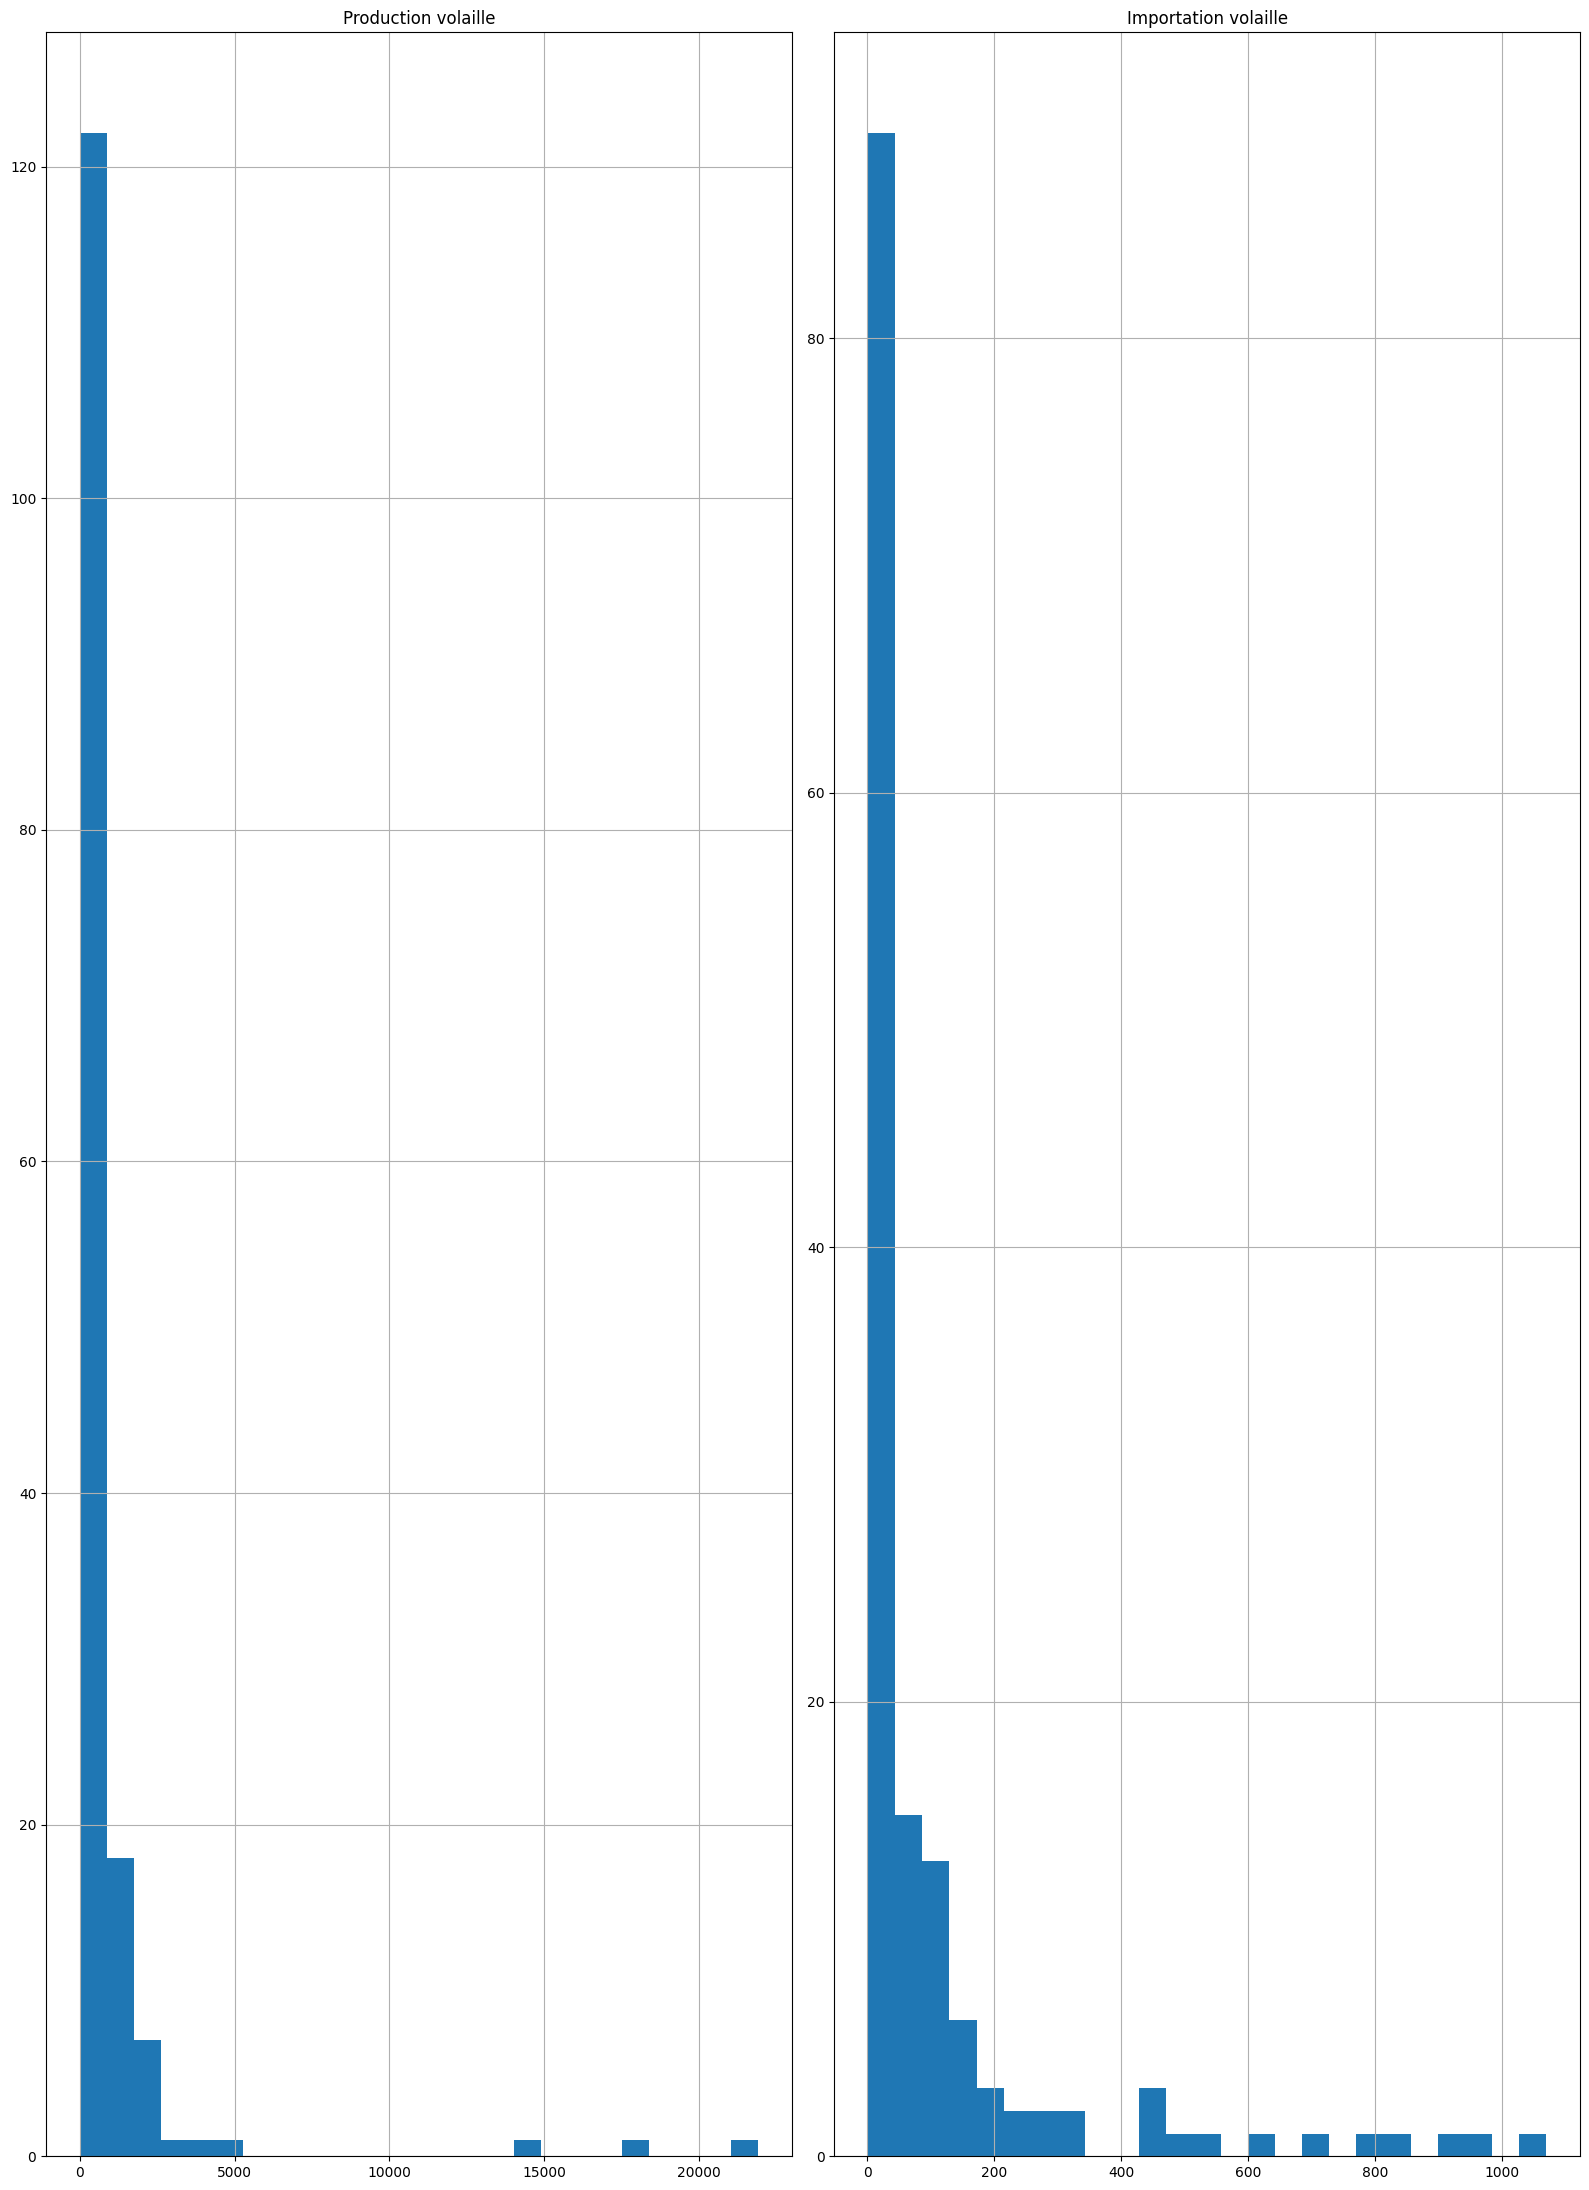

In [69]:
# Visualisation de la distribution des variables
df_volaille[["Production volaille", "Importation volaille"]].hist(
    bins=25, figsize=(16, 22)
)
plt.tight_layout()
plt.show()

Les deux variables sont fortement asymétriques à droite. La médiane sera donc utilisée pour imputer

In [70]:
# Imputation par la médiane
for col in ["Production volaille", "Importation volaille"]:
    df_volaille[col] = df_volaille.groupby("IC")[col].transform(
        lambda x: x.fillna(x.median())
    )

In [71]:
# Vérification finale
df_volaille.describe()

,CC,PV,Internet,Chomage,Tourisme,Evolution tourisme,LPI,Distance capitale,RL,RQ,Population,Evolution population,Production volaille,Importation volaille,Dispo alim volaille
count,164.000000,164.000000,164.000000,164.000000,1.640000e+02,164.000000,164.000000,164.00000,164.000000,164.000000,1.640000e+02,164.000000,164.000000,164.000000,164.000000
mean,46.796098,64.713496,54.159778,7.557274,1.253162e+07,69.089492,2.881463,5766.27439,56.121571,55.838049,4.380902e+04,5.483402,744.420732,93.402439,7.046402
std,19.731865,14.338753,26.936420,5.599068,2.927122e+07,105.911287,0.535716,3765.23565,16.233513,14.241108,1.565328e+05,5.072629,2528.499698,188.697813,5.537564
min,14.170000,21.244270,4.000000,0.141000,0.000000e+00,-70.107108,1.950000,0.00000,18.844823,25.990000,5.204500e+01,-5.434483,1.000000,1.000000,0.150000
25%,31.572500,55.390281,27.200001,3.771750,6.587500e+05,8.779110,2.530000,2227.00000,43.822409,44.702500,2.938805e+03,1.788537,22.750000,9.000000,2.165000
50%,42.580000,65.551480,58.025813,5.592000,2.484000e+06,40.576189,2.700000,5443.50000,52.002050,53.805000,9.757833e+03,4.763012,91.500000,17.000000,6.405000
75%,59.990000,77.267999,76.966724,9.575000,8.492500e+06,93.442002,3.205000,8542.25000,67.677028,64.545000,3.118956e+04,9.091442,409.750000,82.500000,9.972500
max,94.470000,91.388422,98.255201,27.035000,2.072740e+08,778.048780,4.200000,19020.00000,92.925652,89.430000,1.421022e+06,23.935417,21914.000000,1069.000000,27.870000


Les données de la population mondiale proviennent de la FAO et t été converties directement en milliers pour faciliter le calcul de couverture mondiale.

In [72]:
# Vérification finale
population_mondiale_2017 = 7540000
print(f"NaN restants : {df_volaille[pestel].isnull().sum().sum()}")
print(f"Pays : {len(df_volaille)}")
print(
    f"Couverture population mondiale : {df_volaille['Population'].sum()/ population_mondiale_2017 * 100:.2f} %"
)

NaN restants : 0
Pays : 164
Couverture population mondiale : 95.29 %


Notre dataset final comporte 164 pays couvrant plus de 95,29% de la population mondiale ce qui dépasse largement le seuil de 60% exigé par le brief. Plus aucune valeurs n'est manquante. Nous pouvons passer à l'étude des outliers.

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">2.7 Étude des outliers </h3>
</div>

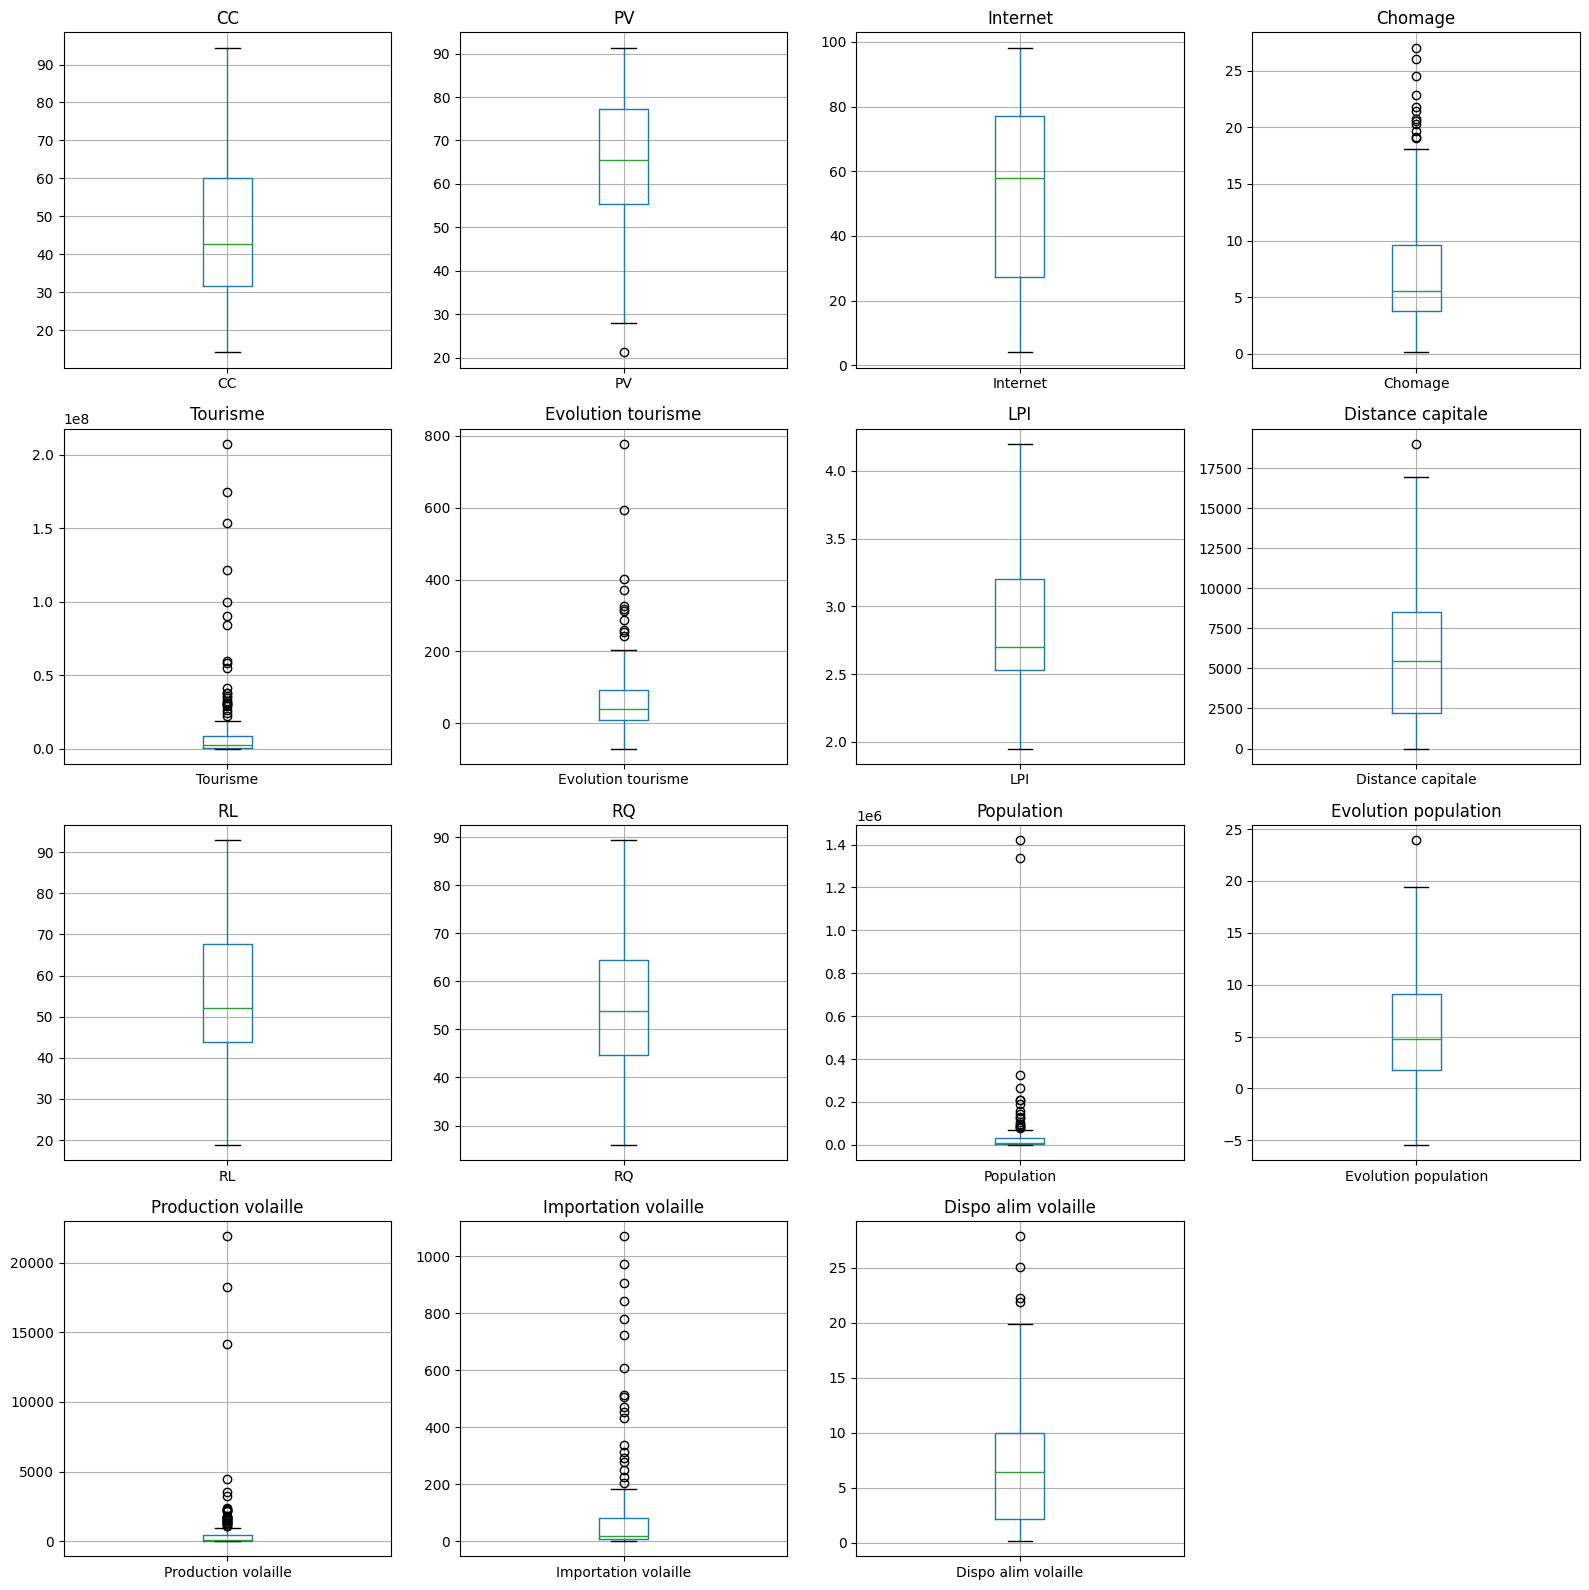

In [73]:
# Distribution de chaque variable
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(pestel):
    df_volaille.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)

for j in range(len(pestel), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

Les boxplots mettent en évidence 2 types de variables: Les variables à distribution équilibrée et les variables à forte asymétrie avec des outliers. Ces outliers reflètent la réalité économique et démographique mondiale. Quelques pays géants concentrent une part disproportionnée des variables. Plutôt que de les supprimer, nous leur appliquerons une transformation logarithmique. Cette transformation compresse les écarts extrêmes, rapproche la distribution d'une forme gaussienne et évite que des pays ne dominent les premières composantes de l'ACP sans perdre d'information. Les variables concernées sont la population,le tourisme, la production et importation de volaille.

In [74]:
# Transformation log
var_log = ["Tourisme", "Population", "Production volaille", "Importation volaille"]
for col in var_log:
    df_volaille[col + "_log"] = np.log1p(df_volaille[col])

In [75]:
# Nouvelle variable log
var_log_1 = [
    "Tourisme_log",
    "Population_log",
    "Production volaille_log",
    "Importation volaille_log",
]

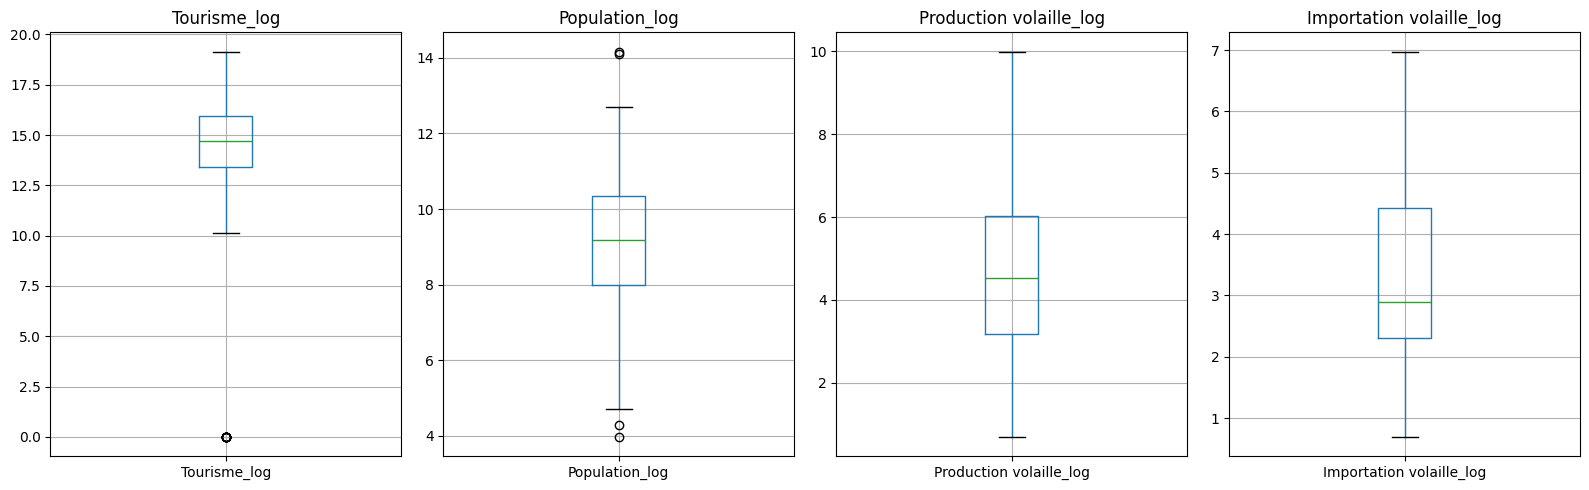

In [76]:
# Confirmation visuelle de la transformation log
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i, col in enumerate(var_log_1):
    df_volaille.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

La transformation log a efficacement aplati les distributions, les boites sont plus centrées et proportionnées.  Elle a permis de réduire l'influence disproportionnée des pays outliers(les très grandes puissances) et elle permettra à l'ACP de mieux représenter la diversité de tous les pays de l'échantillon. Enfin, une simulation a été faite sans transformation log et grâce à cette dernière nous captons 3% de variance supplémentaire lors de l'ACP.

<div style="background-color: #4ECDC4;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Etape 3 - Préparation à l'ACP</h2>
</div>

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">3.1 Centrage-réduction </h3>
</div>

In [77]:
# Liste finale des variables pour l'ACP
var_acp = [col for col in pestel if col not in var_log] + var_log_1
var_acp

['CC',
 'PV',
 'Internet',
 'Chomage',
 'Evolution tourisme',
 'LPI',
 'Distance capitale',
 'RL',
 'RQ',
 'Evolution population',
 'Dispo alim volaille',
 'Tourisme_log',
 'Population_log',
 'Production volaille_log',
 'Importation volaille_log']

In [78]:
# Centrage et réduction
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(df_volaille[var_acp])
df_scaled = pd.DataFrame(x_scaled, columns=var_acp, index=df_volaille["Name"])
df_scaled.head()

,CC,PV,Internet,Chomage,Evolution tourisme,LPI,Distance capitale,RL,RQ,Evolution population,Dispo alim volaille,Tourisme_log,Population_log,Production volaille_log,Importation volaille_log
Name,,,,,,,,,,,,,,,
Afghanistan,-1.534500,-3.040875,-1.514095,0.649721,-0.654332,-1.744051,-0.037636,-1.644200,-1.642391,1.383067,-1.178556,-3.499538,0.772158,-0.595999,0.082668
Albania,-0.528991,0.278376,0.306851,1.085410,1.812074,-0.414663,-1.114429,-0.166705,0.054372,-1.217903,-0.142447,0.364739,-0.581678,-0.950067,0.249696
Algeria,-0.502556,-1.028091,-0.240882,0.795906,-0.291427,-0.807862,-1.180496,-0.870569,-1.119768,0.600207,-0.919529,0.180567,0.842362,0.499455,-1.383214
Angola,-1.407922,-0.559329,-1.048618,1.623033,-0.760636,-1.556814,0.150444,-1.364096,-1.379671,1.804756,-0.624274,-0.379685,0.667026,-0.404484,1.500064
Argentina,-0.129430,0.368685,0.749795,0.141478,-0.249103,0.015984,1.377753,-0.131352,-0.202713,-0.268365,1.174425,0.432524,0.874301,1.500238,-0.683810


In [79]:
# Vérification du scaling avec la moyenne et l'écart-type
df_scaled.describe().round(2).loc[["mean", "std"]]

,CC,PV,Internet,Chomage,Evolution tourisme,LPI,Distance capitale,RL,RQ,Evolution population,Dispo alim volaille,Tourisme_log,Population_log,Production volaille_log,Importation volaille_log
mean,0.0,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,-0.0,-0.0,0.0,-0.0,0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


Toutes les variables ont bien une moyenne de 0 et un écart-type de 1. Le centrage-réduction a été fait avec succès. Toutes les variables ont la même échelle et aucune n'écrasera une autre lors de l'ACP

<div style="background-color: #4ECDC4;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Etape 4 - Matrice de corrélation</h2>
</div>

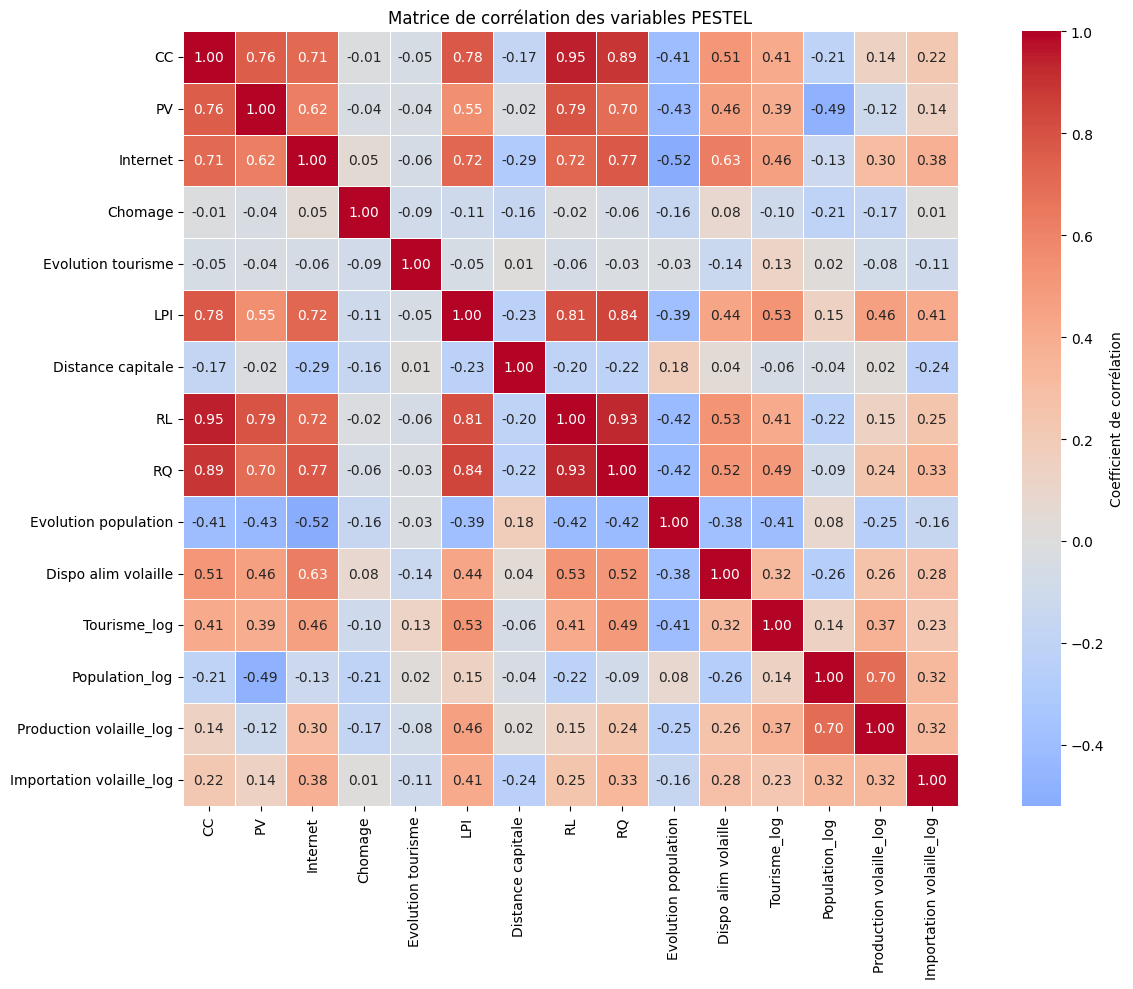

In [80]:
# Heat map de corrélations des variables PESTEL
plt.figure(figsize=(14, 10))
sns.heatmap(
    df_volaille[var_acp].corr().round(2),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Coefficient de corrélation"},
)
plt.title("Matrice de corrélation des variables PESTEL")
plt.tight_layout()
plt.show()

La matrice de corrélation indique de fortes corrélations entre certains groupes de variables. Un premier groupe se compose des indices de gouvernance (CC,PV,RL,RQ) avec le LPI et l'accès à internet qui sont fortement corrélés entre eux. Un deuxième groupe avec la population, l'importation et la production de volaille. Enfin, certaines variables comme le chômage, l'évolution de la population et la distance entre capitales forment un troisième groupe de variables qui restent indépendantes des autres. Ces corrélations indiquent donc une possible redondance entre les variables justifiant ainsi le recours à l'ACP qui va venir réduire la dimensionnalité des variables tout en conservant l'information essentielle.

<div style="background-color: #4ECDC4;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Etape 5 - Export des fichiers pour l'ACP</h2>
</div>

In [81]:
# Export des fichiers
df_scaled.to_csv("../data/df_scaled.csv")
df_volaille.to_csv("../data/df_volaille_final.csv")
print("Fichiers exportés avec succès")

Fichiers exportés avec succès


Conclusion:

Notre dataset de 164 pays (couvrant 95,29% de la population mondiale) a été complètement nettoyé avec une stratégie d'imputation basée sur le niveau de richesse (IC) et sur les spécificités de chaque variable. Une transformation logarithmique a été appliquée aux variables fortement asymétrique (population, tourisme, production et importation de volaille) afin de réduire l'influence des pays géants sur la future ACP. Les variables ont ensuite été centrées-réduites pour garantir une analyse équitable. Enfin, la matrice de corrélation révèle 3 grands groupes de variables, confirmant la pertinence d'une ACP dans le notebook suivant.